# 03 — Modelling

**Input:** `data/processed/X_train.parquet`, `X_test.parquet`, `y_train.parquet`, `y_test.parquet`  
**Output:** `data/processed/xgb_best.pkl`, `data/processed/y_proba.parquet`

Steps:
1. Baseline cross-validation (3 models)
2. Optuna hyperparameter tuning
3. Final model training
4. ROC curve comparison

> **Note on SMOTE placement:** oversampling is applied inside each CV fold  
> via an imbalanced-learn Pipeline. Fitting SMOTE before CV would leak  
> synthetic samples into validation folds and inflate recall scores.

In [1]:
!pip install optuna xgboost imbalanced-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 13.3 MB/s eta 0:00:08
   - -------------------------------------- 4.5/101.7 MB 11.6 MB/s eta 0:00:09
   -- ------------------------------------- 6.3/101.7 MB 10.6 MB/s eta 0:00:10
   --- ------------------------------------ 8.1/101.7 MB 10.2 MB/s eta 0:00:10
   ---- ----------------------------------- 10.2/101.7 MB 9.8 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/101.7 MB 9.6 MB/s eta 0:00:10
   ----- ---------------------------------- 13.6/101.7 MB 9.6 MB/s eta 0:00:10
   ------ --------------------------------- 15.5/101.7 MB 9.3 MB/s eta 0:00:10
   ------ --------------------------------- 17.0/101.7 MB 9.1 MB/s eta 0:00:10
   ------- -------------------------------- 19.1/101.7 MB 9.2 MB/s eta 0:00:09
   -------- ------------------------------- 21.2/101.7 MB 9.2 MB/s eta 0:00:09
   --------- ------------------------------ 23.1/101.7 MB 9.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import RocCurveDisplay, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

X_train = pd.read_parquet('data/processed/X_train.parquet')
X_test  = pd.read_parquet('data/processed/X_test.parquet')
y_train = pd.read_parquet('data/processed/y_train.parquet').squeeze()
y_test  = pd.read_parquet('data/processed/y_test.parquet').squeeze()

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 8,000 | Test: 2,000


## 1. Baseline cross-validation

Three models across the complexity spectrum. This establishes whether
gradient boosting's added complexity is actually justified on this dataset.

In [3]:
def make_pipeline(model):
    """Scale → SMOTE → model. Scaling before SMOTE ensures synthetic
    samples are generated in normalised space."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('model',  model),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'recall': 'recall', 'precision': 'precision'}

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost (default)':   xgb.XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42),
}

cv_results = {}
print(f'{'Model':<25}  {'AUC':>7}  {'F1':>7}  {'Recall':>7}  {'Precision':>9}')
print('-' * 60)

for name, model in baseline_models.items():
    pipeline = make_pipeline(model)
    results  = cross_validate(pipeline, X_train, y_train,
                              cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: results[f'test_{m}'].mean() for m in scoring}
    r = cv_results[name]
    print(f'{name:<25}  {r["roc_auc"]:>7.4f}  {r["f1"]:>7.4f}  '
          f'{r["recall"]:>7.4f}  {r["precision"]:>9.4f}')

Model                          AUC       F1   Recall  Precision
------------------------------------------------------------
Logistic Regression         0.9163   0.8228   0.7982     0.8490
Random Forest               0.9299   0.8383   0.8063     0.8730
XGBoost (default)           0.9239   0.8312   0.8069     0.8571


## 2. Optuna hyperparameter tuning

TPE sampler with 50 trials. More sample-efficient than GridSearchCV
when the search space has more than 3 dimensions.

**Runtime:** ~3–5 minutes on this dataset size.

In [4]:
def optuna_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        # scale_pos_weight complements SMOTE — Optuna finds the right balance
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        'eval_metric':      'logloss',
        'random_state':     42,
    }
    pipeline = make_pipeline(xgb.XGBClassifier(**params))
    scores   = cross_val_score(pipeline, X_train, y_train,
                               cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest CV AUC : {study.best_value:.4f}')
print('Best params :', best_params)

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV AUC : 0.9335
Best params : {'n_estimators': 463, 'max_depth': 4, 'learning_rate': 0.016413508386258106, 'subsample': 0.6510956276731718, 'colsample_bytree': 0.643128418563818, 'min_child_weight': 7, 'gamma': 3.9993247977478514, 'scale_pos_weight': 4.0545980455084445}


## 3. Final model training

CV was used for honest evaluation. The final model is trained on the full
training set with the tuned parameters before evaluating on the held-out test set.

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Apply SMOTE + scaling to the full training set for the final fit
scaler = StandardScaler()
smote  = SMOTE(random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
X_test_scaled  = scaler.transform(X_test)

final_model = xgb.XGBClassifier(
    **best_params, eval_metric='logloss', random_state=42
)
final_model.fit(X_train_res, y_train_res)

y_proba = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.94      0.52      0.67       913
     Churned       0.71      0.97      0.82      1087

    accuracy                           0.77      2000
   macro avg       0.82      0.75      0.74      2000
weighted avg       0.81      0.77      0.75      2000



## 4. ROC curve comparison

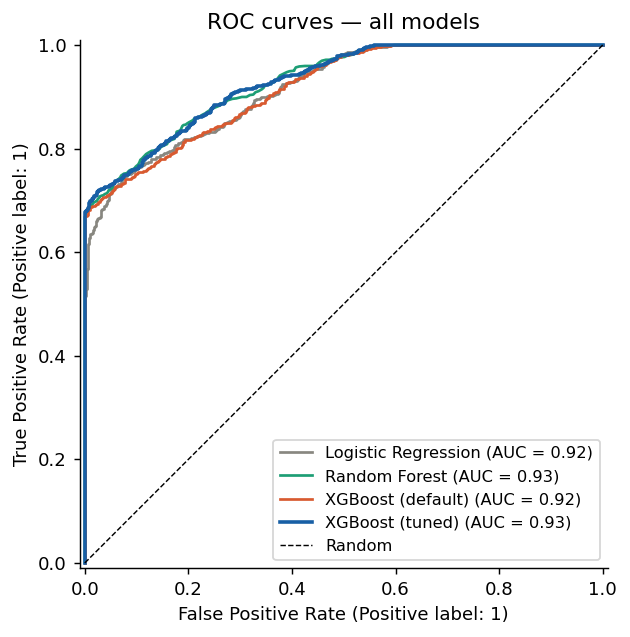

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

# Fit each baseline on full train set for ROC comparison
colors = ['#888780', '#1D9E75', '#D85A30']
for (name, model), color in zip(baseline_models.items(), colors):
    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test,
                                   ax=ax, name=name, color=color, lw=1.5)

# Tuned XGBoost on top
from sklearn.metrics import RocCurveDisplay as RCD
RCD.from_predictions(y_test, y_proba, ax=ax,
                     name='XGBoost (tuned)', color='#185FA5', lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_title('ROC curves — all models')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/03_roc_curves.png', bbox_inches='tight')
plt.show()

## Save model and predictions

In [7]:
with open('data/processed/xgb_best.pkl', 'wb') as f:
    pickle.dump({'model': final_model, 'scaler': scaler}, f)

pd.DataFrame({'y_proba': y_proba}, index=X_test.index).to_parquet(
    'data/processed/y_proba.parquet'
)

print('Saved model → data/processed/xgb_best.pkl')
print('Saved probabilities → data/processed/y_proba.parquet')

Saved model → data/processed/xgb_best.pkl
Saved probabilities → data/processed/y_proba.parquet
